In [1]:
import umap
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
data=load_iris()
x=data.data
y=data.target
p=pd.DataFrame(x,columns=data.feature_names)
g=pd.DataFrame(y,columns=['target'])
print(p.shape)
p.head()

(150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x_train)
x_tscaled=scaler.transform(x_test)
u_map=umap.UMAP(n_components=3)
x_map=u_map.fit_transform(x_scaled)
x_tmap=u_map.transform(x_tscaled)
x_maps=pd.DataFrame(x_map,columns=['umap1','umap2','umap3'])
print(x_maps.shape)
x_maps.head()

(120, 3)


,umap1,umap2,umap3
0,-1.236501,0.998531,7.455912
1,-2.727638,0.480464,7.177122
2,9.988492,5.531497,4.758804
3,-0.602451,1.029807,7.409786
4,0.048253,1.662057,7.786094


In [11]:
model=LogisticRegression()
model.fit(x_map,y_train)
y_pred=model.predict(x_tmap)
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)


0.9666666666666667


In [12]:
print("Train score:",model.score(x_map,y_train))
print("Test score:",model.score(x_tmap,y_test))
print("accuracy_score:",accuracy_score(y_test,y_pred))
print(p.shape)
print(x_maps.shape)
print(p.head())
print(x_maps.head())

Train score: 0.9583333333333334
Test score: 0.9666666666666667
accuracy_score: 0.9666666666666667
(150, 4)
(120, 3)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
       umap1     umap2        u3
0  -2.799989  3.782496  1.317626
1  -1.792498  3.528585  2.011543
2  10.340416  8.999063  4.809647
3  -3.251458  3.863227  1.048963
4  -4.038822  3.302088  0.407535


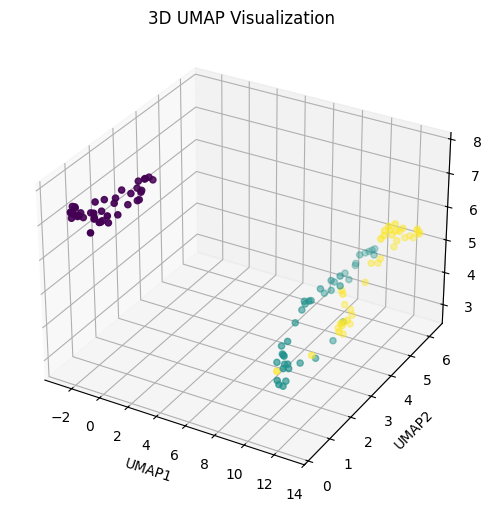

In [16]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    x_maps['umap1'],
    x_maps['umap2'],
    x_maps['umap3'],
    c=y_train
)

ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_zlabel("UMAP3")

plt.title("3D UMAP Visualization")

plt.show()